In [4]:
!pip install folium

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import folium
import geopandas as gpd
import rasterio
import glob
from pathlib import Path
from datetime import datetime
import networkx as nx
from shapely.geometry import Point, LineString
import matplotlib.patches as mpatches
import geopandas as gpd
from matplotlib.lines import Line2D

# Data Preparation and Understanding

### Population dataset

In [6]:
# Load the population data into dataframes.
pop_df = pd.read_csv("./data/GDL-Total-area-population-in-millions-data.csv")
pop_df.head()

,Country,Continent,ISO_Code,Level,GDLCODE,Region,2019,2020
0,India,Asia/Pacific,IND,National,INDt,Total,1366.00,1380.00
1,India,Asia/Pacific,IND,Subnat,INDr136,Andaman and Nicobar Islands,0.37,0.36
2,India,Asia/Pacific,IND,Subnat,INDr101,Andhra Pradesh,52.00,51.10
3,India,Asia/Pacific,IND,Subnat,INDr125,Arunachal Pradesh,1.04,1.01
4,India,Asia/Pacific,IND,Subnat,INDr102,Assam,34.80,35.90


In [7]:
# Get dataframe information.
pop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    37 non-null     object 
 1   Continent  37 non-null     object 
 2   ISO_Code   37 non-null     object 
 3   Level      37 non-null     object 
 4   GDLCODE    37 non-null     object 
 5   Region     37 non-null     object 
 6   2019       37 non-null     float64
 7   2020       37 non-null     float64
dtypes: float64(2), object(6)
memory usage: 2.4+ KB


In [8]:
# Remove unneccessary columns.
columns_to_drop = ["Country", "Continent", "ISO_Code", "Level", "GDLCODE"]

pop_df.drop(columns = columns_to_drop, inplace = True)

In [9]:
# Check dataframe statistics
pop_df.describe()

,2019,2020
count,37.000000,37.000000
mean,73.832973,74.582162
std,223.791535,226.220544
min,0.070000,0.060000
25%,1.370000,1.300000
50%,27.600000,26.800000
75%,65.100000,65.700000
max,1366.000000,1380.000000


- The population data for India in 2019 and 2020 shows a slight overall increase, with the mean rising from **37.94 million to 38.32 million**. 

- The high standard deviation (**49.83 in 2019 and 50.95 in 2020**) indicates significant variation across regions.

- The median population remains relatively stable (**23.85 million in 2019 vs. 23.60 million in 2020**), suggesting that half of the regions have populations below this level. 

- The minimum population remains nearly unchanged, while the maximum increased from **231 million to 239 million**, reflecting growth in the most populous region.

- The interquartile range remains similar, indicating that population distribution across regions has not changed drastically.

In [10]:
# Check for duplicates.
pop_df.duplicated().sum()

np.int64(0)

In [11]:
# Check for null values.
pop_df.isna().sum()

Region    0
2019      0
2020      0
dtype: int64

### GDP data

In [12]:
# Load the GDP data into dataframes.
gdp_df = pd.read_csv("./data/GDL-Log-Gross-National-Income-per-capita-in-1000-US-Dollars-(2011-PPP)-data.csv")
gdp_df.head()

,Country,Continent,ISO_Code,Level,GDLCODE,Region,2019,2020
0,India,Asia/Pacific,IND,National,INDt,Total,8.788,8.714
1,India,Asia/Pacific,IND,Subnat,INDr136,Andaman and Nicobar Islands,9.272,9.195
2,India,Asia/Pacific,IND,Subnat,INDr101,Andhra Pradesh,8.967,8.892
3,India,Asia/Pacific,IND,Subnat,INDr125,Arunachal Pradesh,9.004,8.929
4,India,Asia/Pacific,IND,Subnat,INDr102,Assam,8.331,8.262


In [13]:
# Check dataframe information.
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Country    37 non-null     object 
 1   Continent  37 non-null     object 
 2   ISO_Code   37 non-null     object 
 3   Level      37 non-null     object 
 4   GDLCODE    37 non-null     object 
 5   Region     37 non-null     object 
 6   2019       37 non-null     float64
 7   2020       37 non-null     float64
dtypes: float64(2), object(6)
memory usage: 2.4+ KB


In [14]:
# Remove unneccessary columns.
columns_to_drop = ["Country", "Continent", "ISO_Code", "Level", "GDLCODE"]

gdp_df.drop(columns = columns_to_drop, inplace = True)

In [15]:
# Check dataframe statistics
gdp_df.describe()

,2019,2020
count,37.000000,37.000000
mean,8.960189,8.885297
std,0.376803,0.373604
min,8.198000,8.130000
25%,8.630000,8.558000
50%,9.031000,8.956000
75%,9.272000,9.195000
max,9.579000,9.499000


- The GDP data for India in 2019 and 2020 shows a slight decline, with the mean decreasing from **8.96 to 8.89**. 

- The standard deviation remains relatively stable (**0.38 in 2019 vs. 0.38 in 2020**), indicating minimal variation across regions. 

- The median GDP also declined slightly (**9.04 in 2019 to 8.96 in 2020**), suggesting a general downward trend. 

- The maximum GDP dropped from **9.58 to 9.50**, while the minimum also decreased from **8.20 to 8.13**, reflecting a broad-based contraction. 

- The interquartile range (IQR) remains similar, indicating that the distribution of GDP values across regions has not changed significantly.

In [16]:
# Check for duplicates.
gdp_df.duplicated().sum()

np.int64(0)

In [17]:
# Check for null values.
gdp_df.isna().sum()

Region    0
2019      0
2020      0
dtype: int64

In [18]:
# Merge the datasets.
merged_df = pd.merge(gdp_df, pop_df, on="Region", how = "inner")
merged_df.head()

,Region,2019_x,2020_x,2019_y,2020_y
0,Total,8.788,8.714,1366.00,1380.00
1,Andaman and Nicobar Islands,9.272,9.195,0.37,0.36
2,Andhra Pradesh,8.967,8.892,52.00,51.10
3,Arunachal Pradesh,9.004,8.929,1.04,1.01
4,Assam,8.331,8.262,34.80,35.90


In [19]:
# Melt GDP columns.
gdp_long = merged_df[["Region", "2019_x", "2020_x"]].melt(id_vars=["Region"], 
                                                          var_name="year", 
                                                          value_name="gdp")
gdp_long["year"] = gdp_long["year"].str.replace("_x", "").astype(int)

# Melt population columns.
pop_long = merged_df[["Region", "2019_y", "2020_y"]].melt(id_vars=["Region"], 
                                                          var_name="year", 
                                                          value_name="population")
pop_long["year"] = pop_long["year"].str.replace("_y", "").astype(int)

# Combine melted dataframes.
reshaped_df = pd.merge(gdp_long, pop_long, on=["Region", "year"], how="outer")

# Sort by Region and year.
reshaped_df = reshaped_df.sort_values(by=["Region", "year"]).reset_index(drop=True)
reshaped_df

,Region,year,gdp,population
0,Andaman and Nicobar Islands,2019,9.272,0.37
1,Andaman and Nicobar Islands,2020,9.195,0.36
2,Andhra Pradesh,2019,8.967,52.00
3,Andhra Pradesh,2020,8.892,51.10
4,Arunachal Pradesh,2019,9.004,1.04
...,...,...,...,...
69,Uttar Pradesh,2020,8.443,239.00
70,Uttaranchal,2019,9.087,11.40
71,Uttaranchal,2020,9.011,11.60
72,West Bengal,2019,8.562,102.00


In [20]:
# Check dataframe information.
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Region  37 non-null     object 
 1   2019_x  37 non-null     float64
 2   2020_x  37 non-null     float64
 3   2019_y  37 non-null     float64
 4   2020_y  37 non-null     float64
dtypes: float64(4), object(1)
memory usage: 1.6+ KB


### Nighttime data.

In [21]:
# Load the truck data into dataframes.
nighttime_df = pd.read_csv("data/viirs_annual_pc11dist.csv")
nighttime_df.head()

,pc11_district_id,pc11_state_id,viirs_annual_min,viirs_annual_max,viirs_annual_mean,viirs_annual_sum,viirs_annual_num_cells,category,year
0,532,28,0.000000,47.335991,0.506407,40484.480053,79944.544753,median-masked,2021
1,533,28,0.000000,39.871834,0.901833,35284.502309,39125.317318,median-masked,2021
2,534,28,0.000000,55.269165,1.092501,63880.362758,58471.700079,median-masked,2021
3,535,28,0.000000,47.633114,1.526908,72835.408423,47701.228541,median-masked,2021
4,536,28,11.679568,110.478027,43.376884,49900.414293,1150.391864,median-masked,2021


In [22]:
# Check dataframe information.
nighttime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15360 entries, 0 to 15359
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   pc11_district_id        15360 non-null  int64  
 1   pc11_state_id           15360 non-null  int64  
 2   viirs_annual_min        15360 non-null  float64
 3   viirs_annual_max        15360 non-null  float64
 4   viirs_annual_mean       15360 non-null  float64
 5   viirs_annual_sum        15360 non-null  float64
 6   viirs_annual_num_cells  15360 non-null  float64
 7   category                15360 non-null  object 
 8   year                    15360 non-null  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 1.1+ MB


In [23]:
# Define state IDs and names.
state_id = list(range(1, 36))  
state_name = [
    "Jammu & Kashmir", "Himachal Pradesh", "Punjab", "Chandigarh", "Uttarakhand",
    "Haryana", "Delhi", "Rajasthan", "Uttar Pradesh", "Bihar", "Sikkim",
    "Arunachal Pradesh", "Nagaland", "Manipur", "Mizoram", "Tripura", "Meghalaya",
    "Assam", "West Bengal", "Jharkhand", "Odisha", "Chhattisgarh", "Madhya Pradesh",
    "Gujarat", "Daman & Diu", "Dadra & Nagar Haveli", "Maharashtra", "Andhra Pradesh",
    "Karnataka", "Goa", "Lakshadweep", "Kerala", "Tamil Nadu", "Puducherry",
    "Andaman & Nicobar"
]

# Create a dictionary mapping state IDs to state names.
state_dict = dict(zip(state_id, state_name))

# Map the state names to viirs_df based on state id.
nighttime_df["Region"] = nighttime_df["pc11_state_id"].map(state_dict)

In [24]:
# Filter for 2019-2020.
nighttime_df = nighttime_df[nighttime_df["year"].isin([2019, 2020])]

In [25]:
# Rename columns for clarity.
nighttime_df.rename(columns={
    "viirs_annual_mean": "viirs_mean",
    "viirs_annual_sum": "viirs_sum"
}, inplace=True)

In [26]:
# Aggregate to state level.
nighttime_state = nighttime_df.groupby(["pc11_state_id","Region","year"]).agg({
    "viirs_mean": "mean",  
    "viirs_sum": "sum"     
}).reset_index()


nighttime_state.head()

,pc11_state_id,Region,year,viirs_mean,viirs_sum
0,1,Jammu & Kashmir,2019,0.713755,260222.264499
1,1,Jammu & Kashmir,2020,0.776644,274668.174846
2,2,Himachal Pradesh,2019,0.255061,84888.714241
3,2,Himachal Pradesh,2020,0.242475,80605.107933
4,3,Punjab,2019,1.507757,794208.133853


In [27]:
# Remove the encoded state id.
nighttime_state.drop(columns="pc11_state_id", inplace=True)

In [28]:
# Check dataframe statistics.
nighttime_state[["viirs_mean", "viirs_sum"]].describe()

,viirs_mean,viirs_sum
count,70.000000,7.000000e+01
mean,2.767083,7.034839e+05
std,6.236029,8.649581e+05
min,0.036847,2.350699e+02
25%,0.497632,2.625249e+04
50%,0.745199,2.674452e+05
75%,2.252677,1.215996e+06
max,33.491387,3.433784e+06


In [29]:
# Check for null values.
nighttime_state.isnull().sum()

Region        0
year          0
viirs_mean    0
viirs_sum     0
dtype: int64

In [30]:
# Merge the datasets.
combined_df = pd.merge(reshaped_df, nighttime_state, on=["Region", "year"], how="inner")
combined_df.head()

,Region,year,gdp,population,viirs_mean,viirs_sum
0,Andhra Pradesh,2019,8.967,52.00,2.754767,2.009531e+06
1,Andhra Pradesh,2020,8.892,51.10,2.718202,2.152512e+06
2,Arunachal Pradesh,2019,9.004,1.04,0.036847,2.432774e+04
3,Arunachal Pradesh,2020,8.929,1.01,0.042697,2.919143e+04
4,Assam,2019,8.331,34.80,0.490884,3.476018e+05


In [31]:
# Check dataframe information.
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Region      54 non-null     object 
 1   year        54 non-null     int64  
 2   gdp         54 non-null     float64
 3   population  54 non-null     float64
 4   viirs_mean  54 non-null     float64
 5   viirs_sum   54 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.7+ KB


In [32]:
# Convert year to datetime format.
# combined_df["year"] = pd.to_datetime(combined_df["year"].astype(str) + "-01-01")

In [33]:
# Check for duplicates.
combined_df.duplicated().sum()

np.int64(0)

In [34]:
# Check for null values.
combined_df.isna().sum()

Region        0
year          0
gdp           0
population    0
viirs_mean    0
viirs_sum     0
dtype: int64

### Truck delivery dataset

In [35]:
# Load the data into dataframes.
truck_df = pd.read_excel("data/Delivery truck trip data.xlsx")
truck_df.head()

,GpsProvider,BookingID,Market/Regular,BookingID_Date,vehicle_no,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,...,TRANSPORTATION_DISTANCE_IN_KM,vehicleType,Minimum_kms_to_be_covered_in_a_day,Driver_Name,Driver_MobileNo,customerID,customerNameCode,supplierID,supplierNameCode,Material Shipped
0,CONSENT TRACK,MVCV0000927/082021,Market,2020-08-17 14:59:01.000,KA590408,"TVSLSL-PUZHAL-HUB,CHENNAI,TAMIL NADU","ASHOK LEYLAND PLANT 1- HOSUR,HOSUR,KARNATAKA","13.1550,80.1960","12.7400,77.8200",2020-08-24 00:05:09,...,320.0,NaN,NaN,NaN,NaN,ALLEXCHE45,Ashok leyland limited,VIJEXHOSR7,VIJAY TRANSPORT,BRACKET / GRAB HANDLE
1,VAMOSYS,VCV00014271/082021,Regular,2020-08-27 16:22:22.827,TN30BC5917,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:28,...,103.0,NaN,NaN,RAMESH,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,VJLEXSHE09,VJ LOGISTICS,ZB MODEL PLATE / 3143
2,CONSENT TRACK,VCV00014382/082021,Regular,2020-08-27 17:59:24.987,TN22AR2748,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8710,79.7390","11.8710,79.7390",2020-08-28 09:05:09,...,300.0,NaN,NaN,GIRI,NaN,LUTGCCHE06,Lucas tvs ltd,GSTEXLAK1Q,G.S. TRANSPORT,LETTERING / FUSO
3,VAMOSYS,VCV00014743/082021,Regular,2020-08-28 00:48:24.503,TN28AQ0781,"DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","DAIMLER INDIA COMMERCIAL VEHICLES,KANCHIPURAM,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:31,...,61.0,NaN,NaN,RAVI,NaN,DMREXCHEUX,Daimler india commercial vehicles pvt lt,ARVEXNAM09,ARVINTH TRANSPORT,LU STRUT RA / RADIUS ROD
4,VAMOSYS,VCV00014744/082021,Regular,2020-08-28 01:23:19.243,TN68F1722,"LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","LUCAS TVS LTD-PONDY,PONDY,PONDICHERRY","11.8720,79.6320","11.8720,79.6320",2020-08-28 12:40:29,...,240.0,NaN,NaN,TAMIL,NaN,LUTGCCHE06,Lucas tvs ltd,SRTEXKOR96,SR TRANSPORTS,WISHBONE / V ROD/HDT


In [36]:
# Get dataframe information.
truck_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6880 entries, 0 to 6879
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   GpsProvider                         5927 non-null   object        
 1   BookingID                           6880 non-null   object        
 2   Market/Regular                      6880 non-null   object        
 3   BookingID_Date                      6880 non-null   datetime64[ns]
 4   vehicle_no                          6880 non-null   object        
 5   Origin_Location                     6880 non-null   object        
 6   Destination_Location                6880 non-null   object        
 7   Org_lat_lon                         6880 non-null   object        
 8   Des_lat_lon                         6880 non-null   object        
 9   Data_Ping_time                      5927 non-null   datetime64[ns]
 10  Planned_ETA             

The dataframe consists of 32 columns and 6,880 rows, each representing information related to truck routes in India, such as location, material shipped, date, etc. It is apparent that some columns contain missing or null values, which may require further data cleaning or imputation to ensure accurate analysis and processing.

In [37]:
# Check the statistics.
truck_df.describe()

,BookingID_Date,Data_Ping_time,Curr_lat,Curr_lon,TRANSPORTATION_DISTANCE_IN_KM,Minimum_kms_to_be_covered_in_a_day,Driver_MobileNo
count,6880,5927,5927.000000,5927.000000,6168.000000,2820.000000,2.691000e+03
mean,2020-02-08 05:18:40.453054208,2020-04-06 04:54:24.370193920,18.679995,78.759745,553.856282,250.239362,8.598981e+09
min,2019-03-18 12:19:22,2019-06-07 18:25:10,8.166790,69.657698,0.000000,0.000000,6.000546e+09
25%,2019-10-11 18:47:32.500000,2019-12-01 07:35:10,12.871868,76.891857,40.000000,250.000000,7.651505e+09
50%,2020-01-20 13:49:40.500000,2020-06-19 16:10:08,17.470922,77.843340,160.000000,250.000000,8.930762e+09
75%,2020-07-30 13:46:34.750000128,2020-08-10 15:52:45,23.202009,80.018999,900.000000,250.000000,9.634981e+09
max,2020-12-03 13:10:21,2020-08-28 12:40:31,32.367928,95.529550,2954.700000,275.000000,1.000000e+10
std,NaN,NaN,6.075561,4.216357,758.981836,24.315485,1.131669e+09


 Key statistics show a wide range of values:

 - Transportation distances vary from 0 to 2954.7 km, with a mean of 553.86 km.

 - The data spans from March 2019 to December 2020.

Notably, some columns, such as "Driver_MobileNo," have null values, indicating missing data.

The following columns are deemed unnecessary for the analysis and will be removed:

1. BookingID
2. Vehicle Number
3. Origin Location Code
4. Destination Location Code
5. Driver Mobile Number
6. Customer ID
7. Supplier ID

These columns do not contribute to the analysis and will be dropped to streamline the dataset.

In [38]:
# Drop unnecessary columns.
columns_to_drop = ['BookingID', 'vehicle_no', 'OriginLocation_Code',
                   'DestinationLocation_Code',  'Driver_MobileNo',
                   'customerID', 'supplierID', 'vehicle_no', 'Driver_Name']

truck_df.drop(columns = columns_to_drop, inplace = True)

In [39]:
# Check for duplicates.
truck_df.duplicated().sum()

np.int64(6)

In [40]:
# Drop duplicates.
truck_df.drop_duplicates(inplace = True)

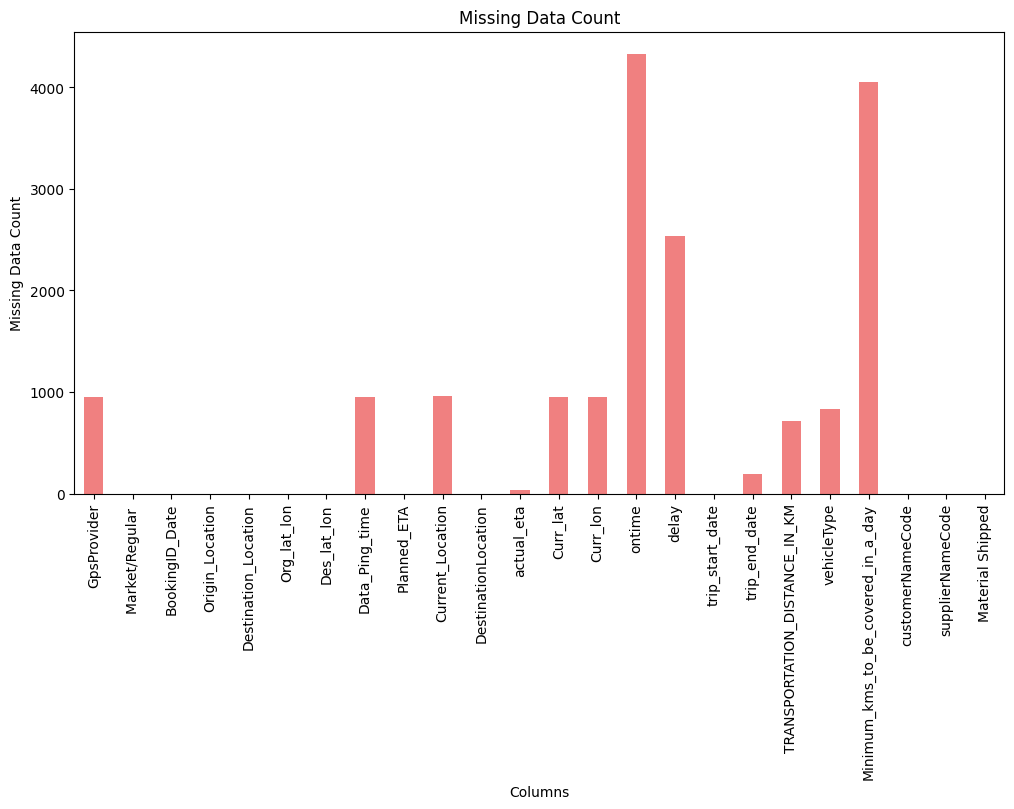

In [41]:
# Check for null values.
missing_data = truck_df.isnull().sum()

# Plot missing data as a bar plot
plt.figure(figsize=(12, 6))
missing_data.plot(kind='bar', color='lightcoral')
plt.title('Missing Data Count')
plt.xlabel('Columns')
plt.ylabel('Missing Data Count')
plt.show()

# Exploratory Data Analysis

<Axes: >

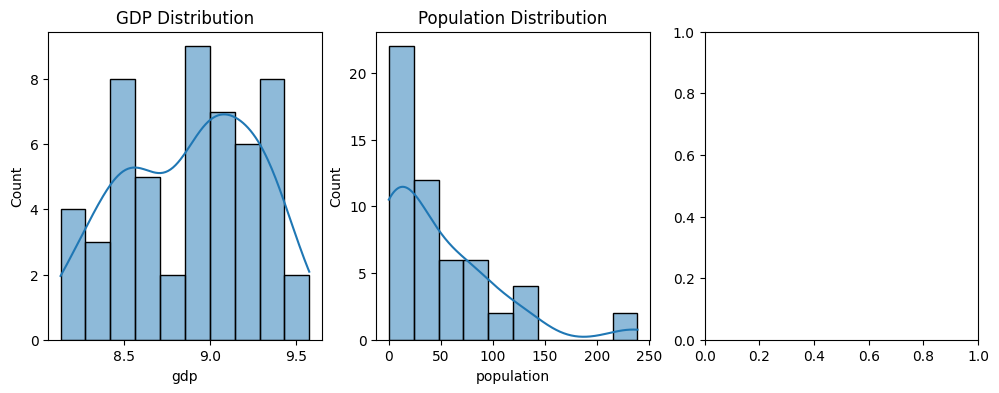

In [42]:
# Plot distribution of the gdp,population and viirs data.
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(combined_df['gdp'], bins=10, kde=True)
plt.title('GDP Distribution')
plt.subplot(1, 3, 2)
sns.histplot(combined_df['population'], bins=10, kde=True)
plt.title('Population Distribution')
plt.subplot(1, 3, 3)
# sns.histplot(combined_df['viirs_mean'], bins=10, kde=True)
# plt.title('VIIRS Mean Distribution')
# plt.tight_layout()
# plt.show()

- GDP shows a bimodal pattern (peaks at 8.5 and 9.25), indicating two economic clusters: less developed and more developed regions.

- Population and VIIRS Mean are right-skewed, with most regions having small populations (0–25 million) and low nighttime light intensity (0–0.5), but a few outliers exhibit high values (up to 250 million and 3, respectively). 

- These patterns suggest economic activity and truck routes are concentrated in populous and urbanized regions, highlighting disparities that could inform targeted development policies.

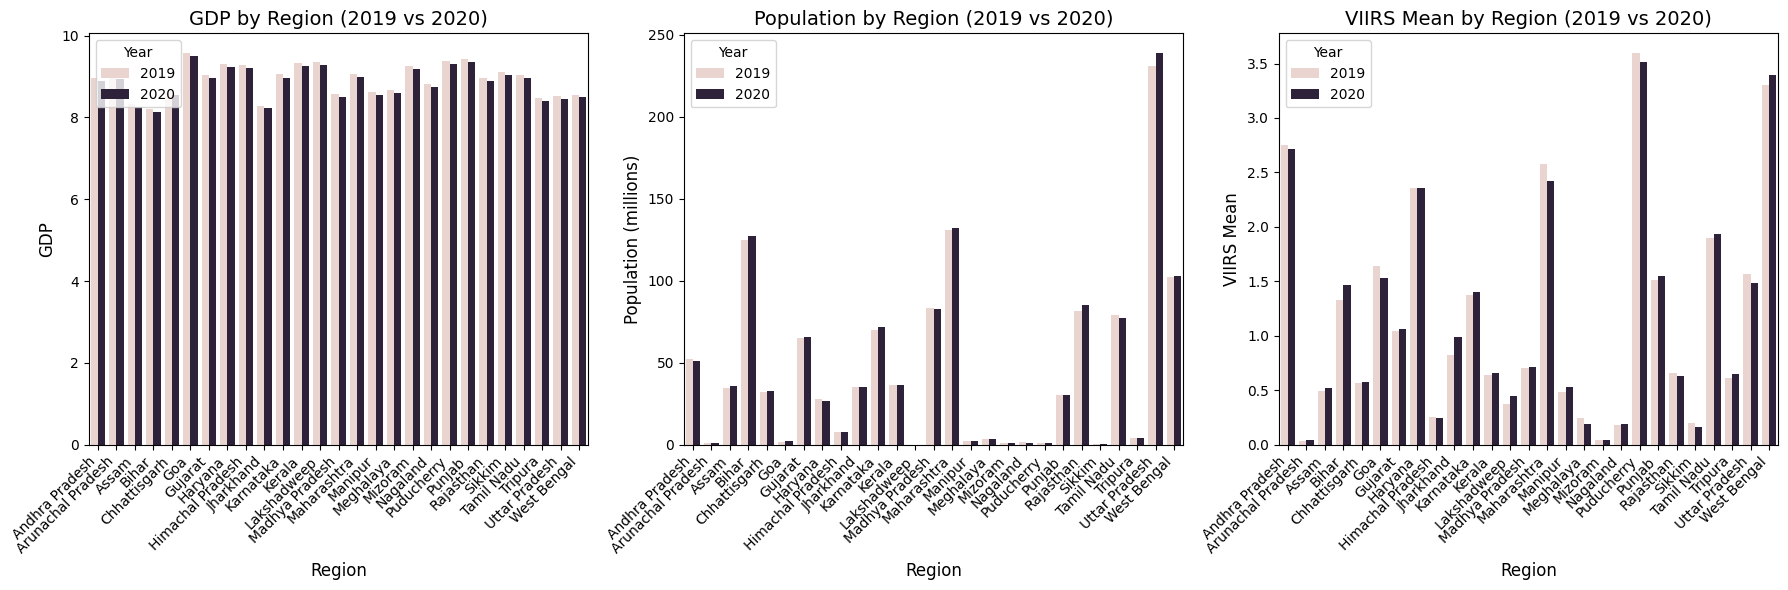

In [43]:
plt.figure(figsize=(18, 6))

# GDP by Region
plt.subplot(1, 3, 1)
sns.barplot(x='Region', y='gdp', hue='year', data=combined_df)
plt.title('GDP by Region (2019 vs 2020)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('GDP', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Year')

# Population by Region
plt.subplot(1, 3, 2)
sns.barplot(x='Region', y='population', hue='year', data=combined_df)
plt.title('Population by Region (2019 vs 2020)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Population (millions)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Year')

# VIIRS Mean by Region
plt.subplot(1, 3, 3)
sns.barplot(x='Region', y='viirs_mean', hue='year', data=combined_df)
plt.title('VIIRS Mean by Region (2019 vs 2020)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('VIIRS Mean', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Year')

plt.tight_layout()
plt.show()

- GDP shows little change between years, with Maharashtra, Tamil Nadu, and Uttar Pradesh leading, while smaller regions like Sikkim and Lakshadweep have the lowest GDP.

- Population remains stable, with Uttar Pradesh, Bihar, and Maharashtra having the largest populations (over 100 million), and smaller regions like Sikkim and Lakshadweep below 1 million. 

- VIIRS Mean, indicating economic activity, also shows minimal change, with Delhi, Chandigarh, and Goa having the highest values (around 2.5–3.0), while rural regions like Arunachal Pradesh and Nagaland have the lowest (below 0.5), highlighting persistent economic disparities.

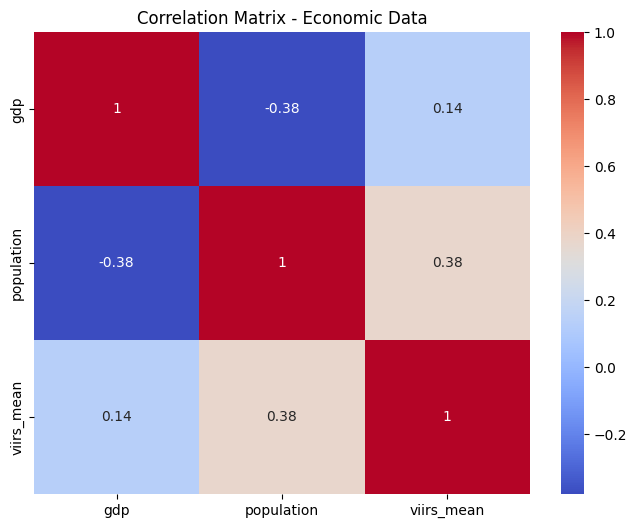

In [44]:
corr_matrix = combined_df[['gdp', 'population', 'viirs_mean']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Economic Data')
plt.show()

- The correlation matrix for economic data in India shows the relationships between GDP, Population, and VIIRS Mean. GDP and Population have a moderate negative correlation (-0.38), indicating that higher GDP regions tend to have smaller populations, and vice versa. 

- Population and VIIRS Mean are moderately positively correlated (0.38), suggesting that more populous regions often have higher nighttime light intensity, reflecting greater economic activity. 

- GDP and VIIRS Mean have a weak positive correlation (0.14), implying a slight tendency for higher GDP regions to have higher economic activity, though the relationship is not strong.

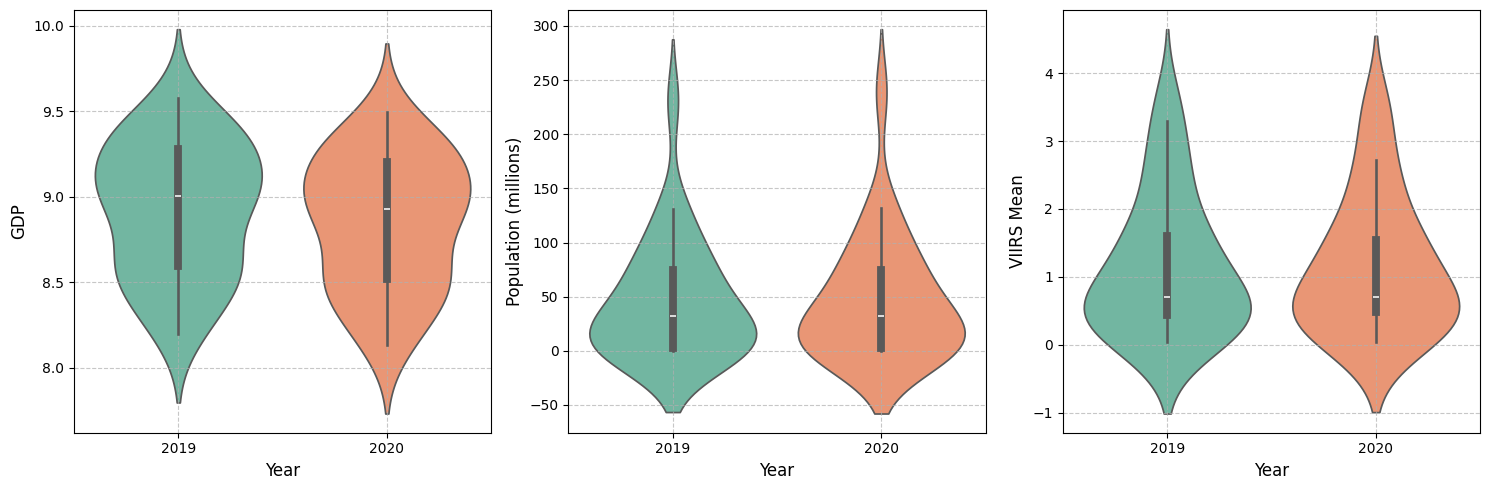

In [45]:
plt.figure(figsize=(15, 5))

# GDP
plt.subplot(1, 3, 1)
sns.violinplot(x='year', y='gdp', hue='year', data=combined_df, palette='Set2', legend=False)
# plt.title('Violin Plot of GDP by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Population
plt.subplot(1, 3, 2)
sns.violinplot(x='year', y='population', hue='year', data=combined_df, palette='Set2', legend=False)
# plt.title('Violin Plot of Population by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Population (millions)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# VIIRS Mean
plt.subplot(1, 3, 3)
sns.violinplot(x='year', y='viirs_mean', hue='year', data=combined_df, palette='Set2', legend=False)
# plt.title('Violin Plot of VIIRS Mean by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('VIIRS Mean', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- The violin plots compare GDP, Population, and VIIRS Mean across Indian regions for 2019 and 2020. GDP distributions are similar between years, ranging from 8.0 to 10.0 with a median around 9.0, showing no significant change. 

- Population distributions are also stable, ranging from 0 to 300 million with a median near 50 million, reflecting consistent population sizes. 

- VIIRS Mean distributions show a slight increase in 2020, ranging from 0 to 4 with a median around 0.5, indicating a minor rise in economic activity as measured by nighttime lights, though the overall spread remains wide.

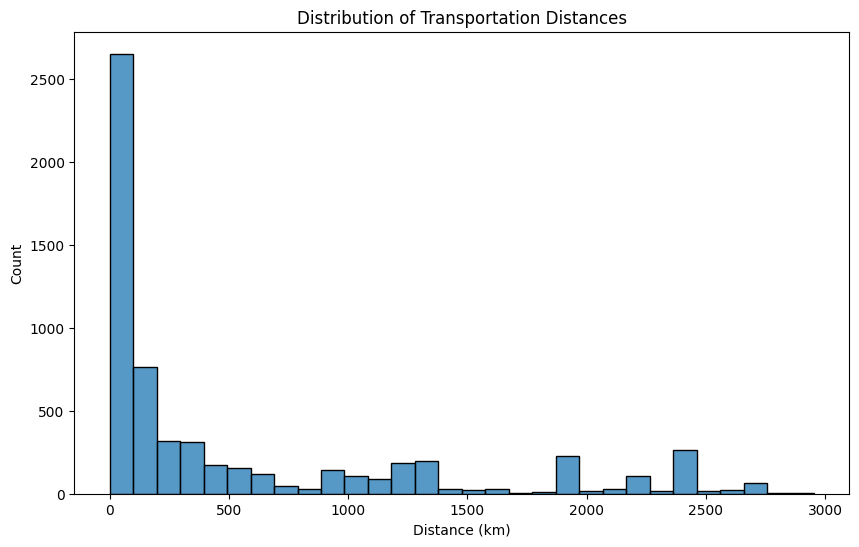

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(truck_df['TRANSPORTATION_DISTANCE_IN_KM'].dropna(), bins=30)
plt.title('Distribution of Transportation Distances')
plt.xlabel('Distance (km)')
plt.ylabel('Count')
plt.show()

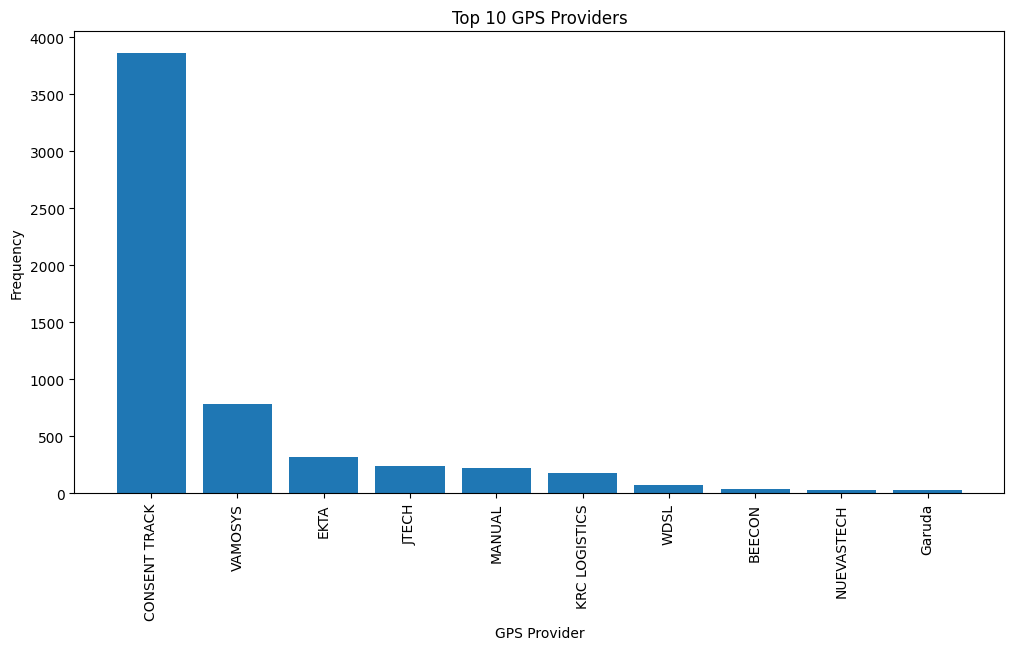

In [47]:
# Check GPS service providers.
gps_provider_counts = truck_df['GpsProvider'].value_counts()

# Plot the top 10 providers.
top_10_gps_providers = gps_provider_counts[:10]

plt.figure(figsize=(12, 6))
plt.bar(top_10_gps_providers.index, top_10_gps_providers.values)
plt.xlabel('GPS Provider')
plt.ylabel('Frequency')
plt.title('Top 10 GPS Providers')
plt.xticks(rotation=90)
plt.show()

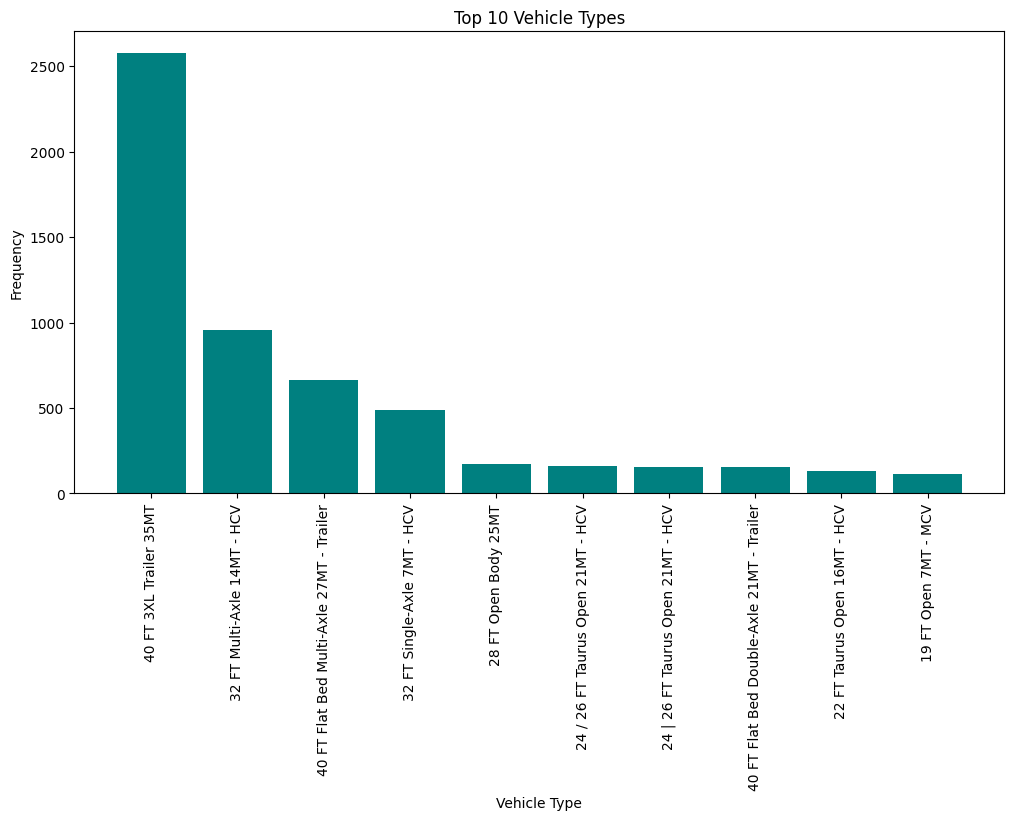

In [48]:
# Compute vehicle type counts.
vehicle_type_counts = truck_df['vehicleType'].value_counts()

# Plot the top 10 vehicle types.
top_10_vehicle_type = vehicle_type_counts[:10]

plt.figure(figsize=(12, 6))
plt.bar(top_10_vehicle_type.index, top_10_vehicle_type.values, color = "teal")
plt.xlabel('Vehicle Type')
plt.ylabel('Frequency')
plt.title('Top 10 Vehicle Types')
plt.xticks(rotation=90)
plt.show()

- **Heavy-Duty Vehicles (HCV & Trailers)** dominate transport, with **40 FT 3XL Trailer (35MT)** leading at **2,574 trips**. Other large vehicles like **40 FT Flat Bed Multi-Axle (27MT)** and **32 FT Multi-Axle (14MT)** are also heavily used.  

- **Medium Commercial Vehicles (MCV)** such as **19 FT Open (7MT)** and **22 FT Taurus Open (16MT)** are used for moderate loads.  

- **Small & Light Commercial Vehicles (LCV)** like **Tata 407 Open (2MT)** and **1.5 MT Pickup** cater to last-mile deliveries.  

- **Rare Vehicle Types**: Specialized or underutilized vehicles include **50 FT Flat Bed (30MT)** and **Mahindra LCV (1MT)**.

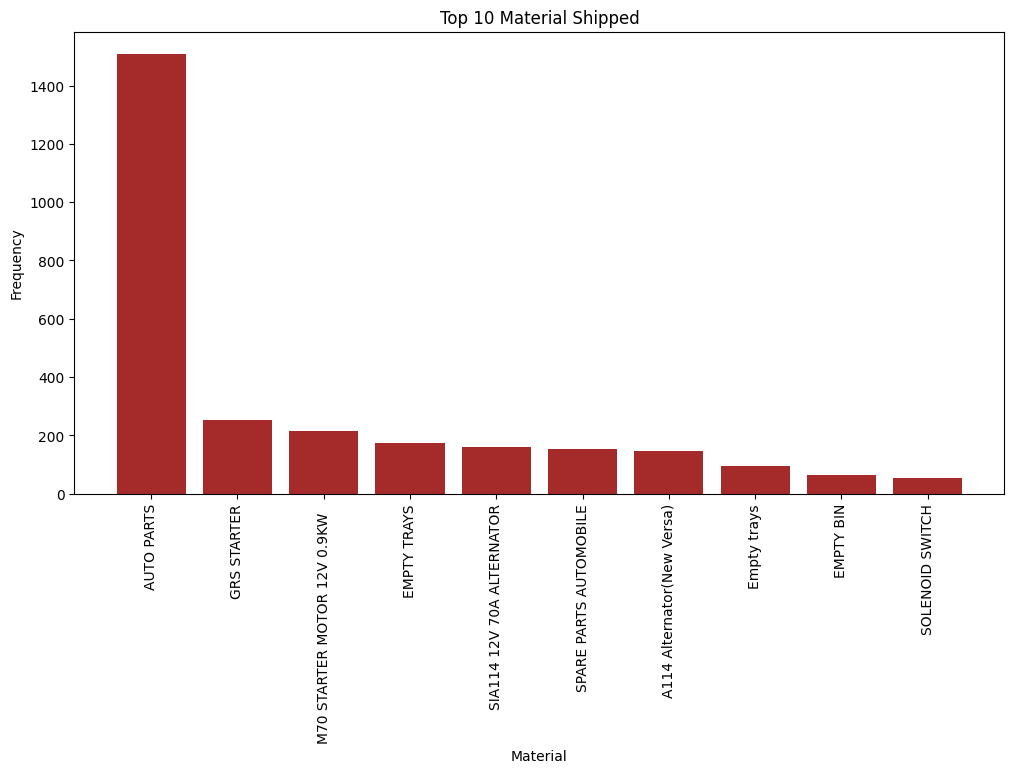

In [49]:
# Compute material counts.
material_counts = truck_df['Material Shipped'].value_counts()

# Plot the top 10 materials.
top_10_material = material_counts[:10]

plt.figure(figsize=(12, 6))
plt.bar(top_10_material.index, top_10_material.values, color = "brown")
plt.xlabel('Material')
plt.ylabel('Frequency')
plt.title('Top 10 Material Shipped')
plt.xticks(rotation=90)
plt.show()

- **Automotive Industry Dominance**: The majority of shipments relate to **auto parts**, with **1,510 entries**, followed by specific components like **GRS Starters (252)** and **M70 Starter Motors (215)**. This suggests a strong focus on vehicle manufacturing and maintenance.  

- **Reusable Packaging**: Items like **empty trays (172)** indicate logistics support, possibly for returnable packaging in supply chains.  

- **Niche & Low-Volume Items**: Some materials, such as **control lever assemblies and mounting brackets**, appear in very low quantities, likely serving specialized needs.

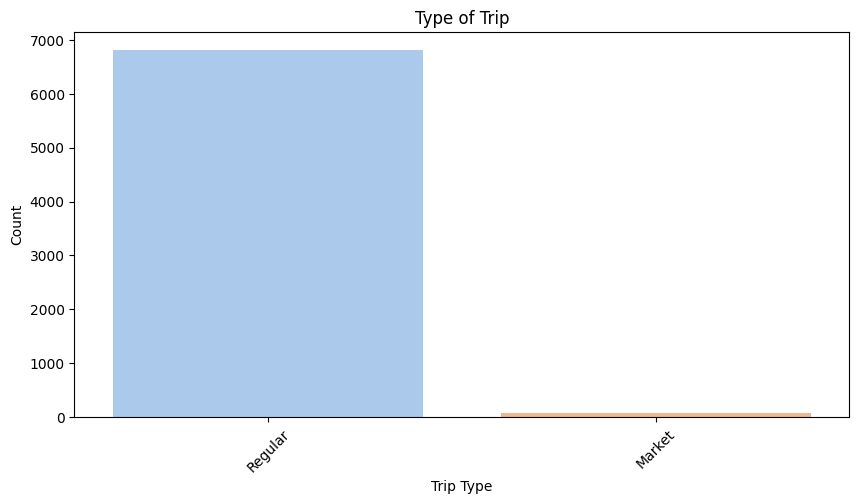

In [50]:
# Compute material counts.
market_counts = truck_df['Market/Regular '].value_counts()

# Plot the top 10 materials.
top_10_market = market_counts[:10]

# Plot the data
plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_market.index, y=top_10_market.values, hue=top_10_market.index, palette="pastel", legend=False)
plt.xlabel('Trip Type')
plt.ylabel('Count')
plt.title('Type of Trip')
plt.xticks(rotation=45)
plt.show()

- Most of the trucks were categorized as "Regular," meaning they belonged to vendors with whom the company had an ongoing contract.

- In contrast, "Market" trucks referred to vendors who operated without a formal contract, likely being engaged on an as-needed basis.

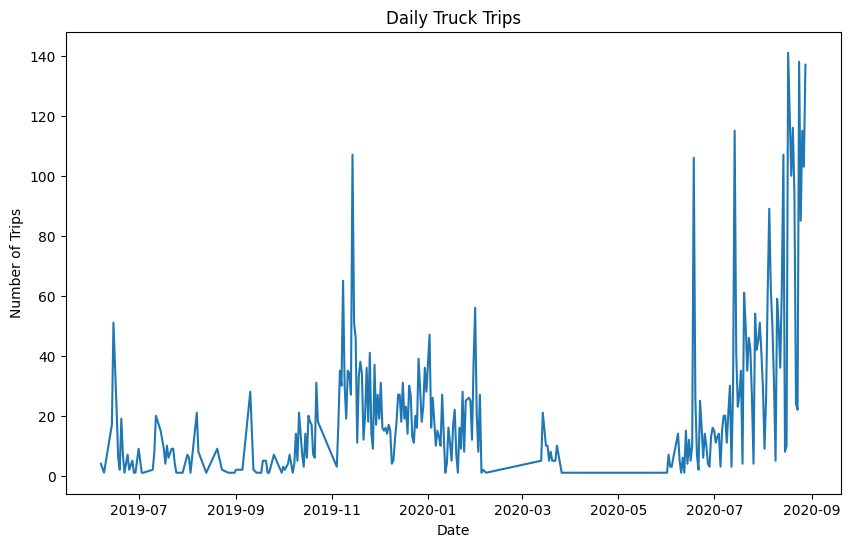

In [51]:
truck_df['Date'] = truck_df['Data_Ping_time'].dt.date
daily_trips = truck_df.groupby('Date').size()
plt.figure(figsize=(10, 6))
daily_trips.plot(kind='line')
plt.title('Daily Truck Trips')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.show()

- The line plot of daily truck trips from July 2019 to September 2020 shows significant fluctuations, with peaks reaching 120–140 trips and troughs near 0.

- High activity occurs in July 2019, October 2019, and July–September 2020, while a sharp decline is observed from March to June 2020, likely due to COVID-19 lockdowns, with trips dropping to near zero in April 2020. Recovery begins in June 2020, with a notable increase in activity by July 2020, reflecting the resumption of economic operations.

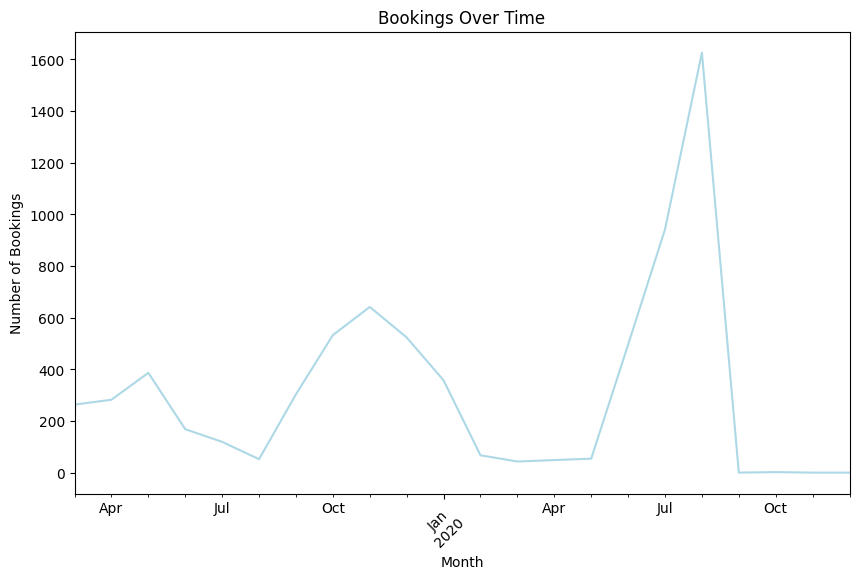

In [52]:
# Group by month and year, then count bookings.
monthly_bookings = truck_df.groupby(truck_df['BookingID_Date'].dt.to_period('M')).size()

# Plot the time series.
plt.figure(figsize=(10, 6))
monthly_bookings.plot(kind='line', color='lightblue')
plt.title('Bookings Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

- There was a noticeable increase in bookings from May to September 2020, while the period from February to April 2020, as well as November to December 2020, showed a plateau.

- From March 2019 onwards, booking trends fluctuated, with a significant spike observed between August and October 2019.

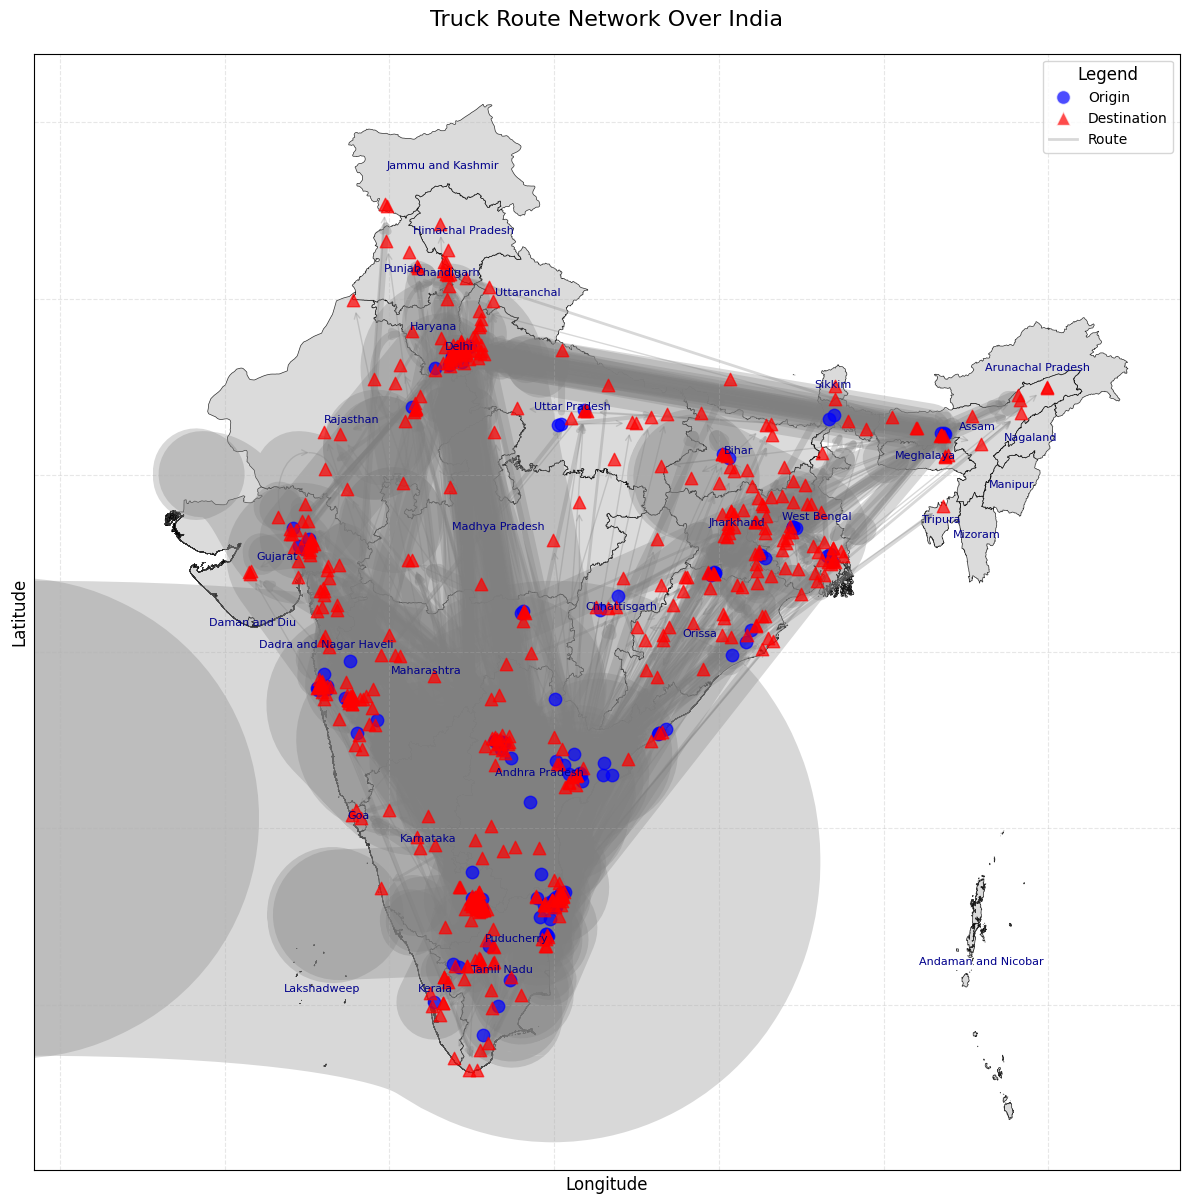

In [53]:
# Load India's map with state boundaries.
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
india = gpd.read_file(url)

# Extract Origin and Destination Coordinates.
truck_df[['Origin_Lat', 'Origin_Lon']] = truck_df['Org_lat_lon'].str.split(',', expand=True).astype(float)
truck_df[['Dest_Lat', 'Dest_Lon']] = truck_df['Des_lat_lon'].str.split(',', expand=True).astype(float)

# Aggregate Routes to Reduce Clutter
# Create a new DataFrame to count the number of trips between each origin-destination pair
truck_df['Route'] = truck_df.apply(lambda row: (
    (row['Origin_Lon'], row['Origin_Lat']),
    (row['Dest_Lon'], row['Dest_Lat'])
), axis=1)
route_counts = truck_df.groupby('Route').size().reset_index(name='Trip_Count')

# Create a Directed Graph
G = nx.DiGraph()

# Add Nodes and Edges with Trip Counts
for _, row in route_counts.iterrows():
    origin, destination = row['Route']
    trip_count = row['Trip_Count']
    G.add_node(origin, pos=origin, type='origin')
    G.add_node(destination, pos=destination, type='destination')
    G.add_edge(origin, destination, weight=trip_count)

# Get node positions
pos = nx.get_node_attributes(G, 'pos')

# Separate nodes by type
origin_nodes = [node for node, data in G.nodes(data=True) if data['type'] == 'origin']
destination_nodes = [node for node, data in G.nodes(data=True) if data['type'] == 'destination']

# Plot the Map and Network Graph
fig, ax = plt.subplots(figsize=(12, 12))

# Plot India map with state boundaries
india.plot(ax=ax, color='lightgrey', edgecolor='black', alpha=0.8, linewidth=0.5)

# Add state labels (centroids of each state)
for idx, row in india.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['NAME_1'],  # Correct column name for state names
        xy=(centroid.x, centroid.y),
        xytext=(0, 0),
        textcoords="offset points",
        fontsize=8,
        color='darkblue',
        ha='center',
        va='center'
    )

# Plot the network graph
# Draw edges (routes) with thickness based on trip count
edges = G.edges(data=True)
edge_weights = [data['weight'] for _, _, data in edges]  # Use trip count as edge weight
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='grey', alpha=0.3, width=edge_weights, arrows=True, arrowstyle='->')

# Draw origin nodes 
nx.draw_networkx_nodes(G, pos, nodelist=origin_nodes, node_size=80, node_color='blue', ax=ax, alpha=0.7, node_shape='o')

# Draw destination nodes
nx.draw_networkx_nodes(G, pos, nodelist=destination_nodes, node_size=80, node_color='red', ax=ax, alpha=0.7, node_shape='^')

# Step 9: Customize the Plot
# Set title and labels with larger fonts
plt.title("Truck Route Network Over India", fontsize=16, pad=20)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Add gridlines for better readability
ax.grid(True, linestyle='--', alpha=0.3)

# Add a Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Origin', markerfacecolor='blue', markersize=10, alpha=0.7),
    Line2D([0], [0], marker='^', color='w', label='Destination', markerfacecolor='red', markersize=10, alpha=0.7),
    Line2D([0], [0], color='grey', lw=2, label='Route', alpha=0.3)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Legend', title_fontsize=12)

plt.tight_layout()
plt.show()

- The truck route network over India, shows dense activity in central and eastern states like Uttar Pradesh, Bihar, and West Bengal, with frequent routes (thick black lines) indicating high traffic, likely due to large populations and economic hubs. 

- Southern states like Tamil Nadu and Andhra Pradesh also exhibit notable activity, while northern and northeastern regions like Himachal Pradesh and Arunachal Pradesh have sparser routes.

# Data Preprocessing

#### Combine all data

In [54]:
truck_df['Origin_Location'] = truck_df['Origin_Location'].apply(lambda x:x.lower())
truck_df['Destination_Location'] = truck_df['Destination_Location'].apply(lambda x:x.lower())

# Extract the state from Origin_Location and Destination_Location.
truck_df['Origin_Region'] = truck_df['Origin_Location'].str.split(',').str[-1].str.strip()
truck_df['Destination_Region'] = truck_df['Destination_Location'].str.split(',').str[-1].str.strip()

# Standardize region names.
region_mapping = {
    "jammu & kashmir": "Jammu & Kashmir",
    "himachal pradesh": "Himachal Pradesh",
    "punjab": "Punjab",
    "chandigarh": "Chandigarh",
    "uttarakhand": "Uttarakhand",
    "haryana": "Haryana",
    "delhi": "Delhi",
    "rajasthan": "Rajasthan",
    "uttar pradesh": "Uttar Pradesh",
    "bihar": "Bihar",
    "sikkim": "Sikkim",
    "arunachal pradesh": "Arunachal Pradesh",
    "nagaland": "Nagaland",
    "manipur": "Manipur",
    "mizoram": "Mizoram",
    "tripura": "Tripura",
    "meghalaya": "Meghalaya",
    "assam": "Assam",
    "west bengal": "West Bengal",
    "jharkhand": "Jharkhand",
    "odisha": "Odisha",
    "chhattisgarh": "Chhattisgarh",
    "madhya pradesh": "Madhya Pradesh",
    "gujarat": "Gujarat",
    "daman & diu": "Daman & Diu",
    "dadra & nagar haveli": "Dadra & Nagar Haveli",
    "maharashtra": "Maharashtra",
    "andhra pradesh": "Andhra Pradesh",
    "karnataka": "Karnataka",
    "goa": "Goa",
    "lakshadweep": "Lakshadweep",
    "kerala": "Kerala",
    "tamil nadu": "Tamil Nadu",
    "puducherry": "Puducherry",
    "andaman & nicobar": "Andaman & Nicobar"
}


truck_df['Origin_Region'] = truck_df['Origin_Region'].map(region_mapping).fillna(truck_df['Origin_Region'])
truck_df['Destination_Region'] = truck_df['Destination_Region'].map(region_mapping).fillna(truck_df['Destination_Region'])

# Extract the year from Data_Ping_time.
truck_df['Year'] = truck_df['Data_Ping_time'].dt.year

In [55]:
# Merge for Origin_Region
all_merged_df = truck_df.merge(
    combined_df,
    how='left',
    left_on=['Origin_Region', 'Year'],
    right_on=['Region', 'year'],
    suffixes=('', '_origin')
)

# Merge for Destination_Region
all_merged_df = all_merged_df.merge(
    combined_df,
    how='left',
    left_on=['Destination_Region', 'Year'],
    right_on=['Region', 'year'],
    suffixes=('_origin', '_destination')
)

# Drop redundant columns.
all_merged_df = all_merged_df.drop(columns=['Region_origin', 'year_origin', 'Region_destination', 'year_destination'])
all_merged_df.head()

,GpsProvider,Market/Regular,BookingID_Date,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,Planned_ETA,Current_Location,...,Destination_Region,Year,gdp_origin,population_origin,viirs_mean_origin,viirs_sum_origin,gdp_destination,population_destination,viirs_mean_destination,viirs_sum_destination
0,CONSENT TRACK,Market,2020-08-17 14:59:01.000,"tvslsl-puzhal-hub,chennai,tamil nadu","ashok leyland plant 1- hosur,hosur,karnataka","13.1550,80.1960","12.7400,77.8200",2020-08-24 00:05:09,2020-08-21 18:59:01,"Vaniyambadi Rd, Valayambattu, Tamil Nadu 63575...",...,Karnataka,2020.0,8.966,77.0,1.933853,1.392379e+06,8.976,71.7,1.398656,1.694715e+06
1,VAMOSYS,Regular,2020-08-27 16:22:22.827,"daimler india commercial vehicles,kanchipuram,...","daimler india commercial vehicles,kanchipuram,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:28,2020-08-31 20:22:22.827000,"Unnamed Road, Oragadam Industrial Corridor, Va...",...,Tamil Nadu,2020.0,8.966,77.0,1.933853,1.392379e+06,8.966,77.0,1.933853,1.392379e+06
2,CONSENT TRACK,Regular,2020-08-27 17:59:24.987,"lucas tvs ltd-pondy,pondy,pondicherry","lucas tvs ltd-pondy,pondy,pondicherry","11.8710,79.7390","11.8710,79.7390",2020-08-28 09:05:09,2020-08-31 21:59:24.987000,"570, National Hwy 48, Shenoy Nagar, Chennai, T...",...,pondicherry,2020.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,VAMOSYS,Regular,2020-08-28 00:48:24.503,"daimler india commercial vehicles,kanchipuram,...","daimler india commercial vehicles,kanchipuram,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:31,2020-09-01 04:48:24.503000,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",...,Tamil Nadu,2020.0,8.966,77.0,1.933853,1.392379e+06,8.966,77.0,1.933853,1.392379e+06
4,VAMOSYS,Regular,2020-08-28 01:23:19.243,"lucas tvs ltd-pondy,pondy,pondicherry","lucas tvs ltd-pondy,pondy,pondicherry","11.8720,79.6320","11.8720,79.6320",2020-08-28 12:40:29,2020-09-01 05:23:19.243000,"Melmaruvathur, Tamil Nadu 603319, India",...,pondicherry,2020.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
# Check dataframe information.
all_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6874 entries, 0 to 6873
Data columns (total 41 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   GpsProvider                         5927 non-null   object        
 1   Market/Regular                      6874 non-null   object        
 2   BookingID_Date                      6874 non-null   datetime64[ns]
 3   Origin_Location                     6874 non-null   object        
 4   Destination_Location                6874 non-null   object        
 5   Org_lat_lon                         6874 non-null   object        
 6   Des_lat_lon                         6874 non-null   object        
 7   Data_Ping_time                      5927 non-null   datetime64[ns]
 8   Planned_ETA                         6874 non-null   object        
 9   Current_Location                    5916 non-null   object        
 10  DestinationLocation     

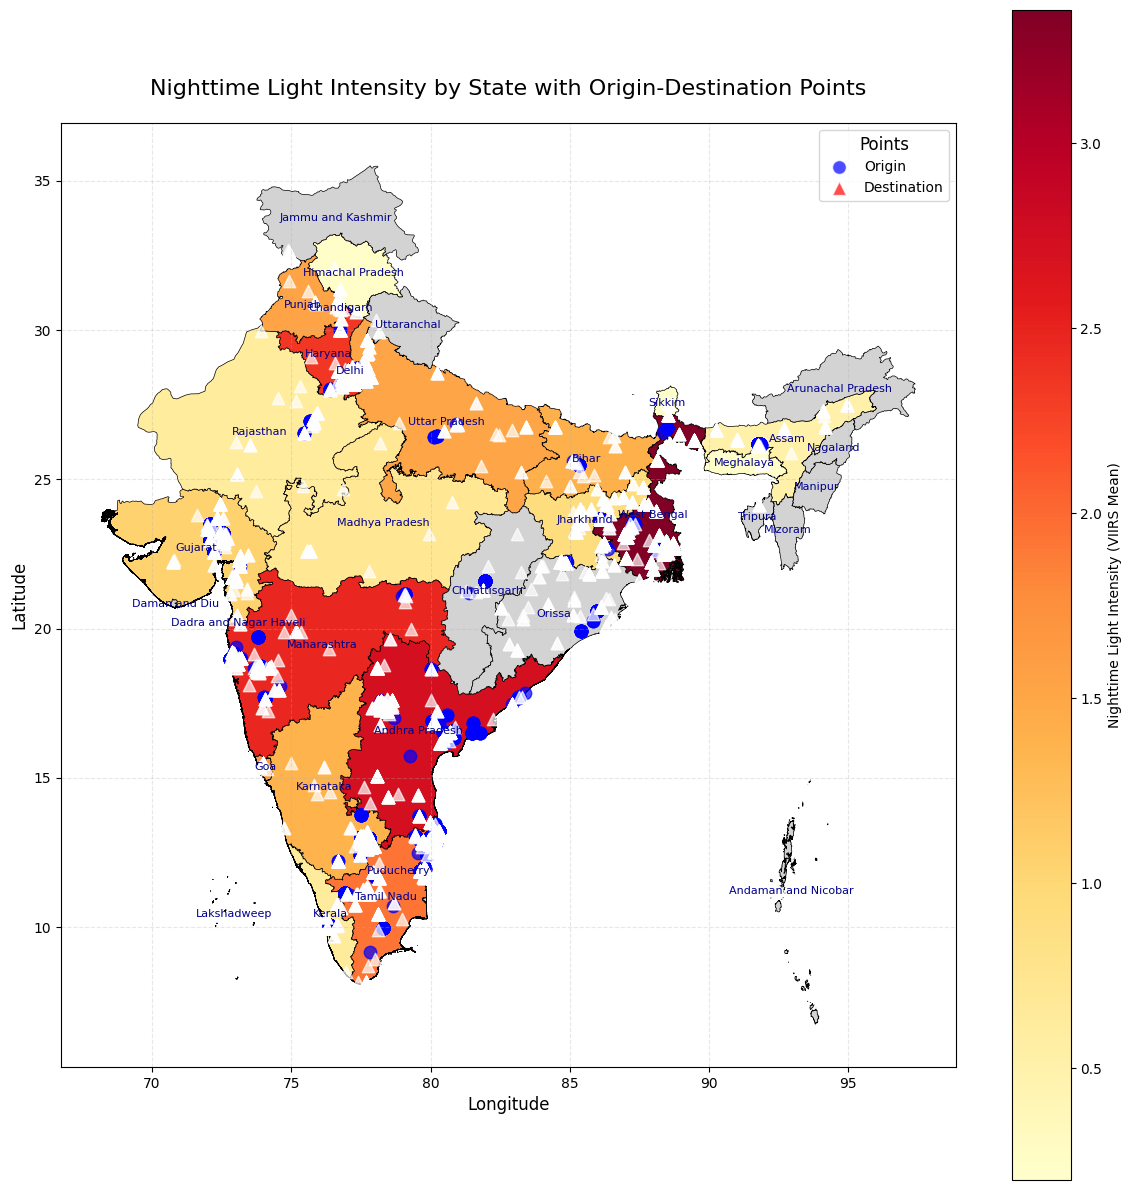

In [57]:
# Load India's map with state boundaries.
url = "https://raw.githubusercontent.com/geohacker/india/master/state/india_state.geojson"
india = gpd.read_file(url)

# Aggregate nighttime intensity by state (Destination_Region)
state_intensity = all_merged_df.groupby('Destination_Region')['viirs_mean_destination'].mean().reset_index()

# Merge the aggregated data with the geospatial data
# Rename 'NAME_1' in GeoJSON to match 'Destination_Region' in DataFrame
india = india.rename(columns={'NAME_1': 'Destination_Region'})
merged = india.merge(state_intensity, on='Destination_Region', how='left')

# Plot the Map
fig, ax = plt.subplots(figsize=(12, 12))

# Plot India map with nighttime intensity
merged.plot(ax=ax, column='viirs_mean_destination', 
            cmap='YlOrRd',  # Yellow-Orange-Red colormap
            edgecolor='black', linewidth=0.5,
            legend=True,
            missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
            legend_kwds={'label': "Nighttime Light Intensity (VIIRS Mean)",
                         'orientation': "vertical"})

# Add state labels (centroids of each state)
for idx, row in india.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row['Destination_Region'],
        xy=(centroid.x, centroid.y),
        xytext=(0, 0),
        textcoords="offset points",
        fontsize=8,
        color='darkblue',
        ha='center',
        va='center'
    )

# Plot origin points
ax.scatter(all_merged_df['Origin_Lon'], all_merged_df['Origin_Lat'], 
           s=80, c='blue', alpha=0.7, marker='o', label='Origin')

# Plot destination points
ax.scatter(all_merged_df['Dest_Lon'], all_merged_df['Dest_Lat'], 
           s=80, c='white', alpha=0.7, marker='^', label='Destination')

# Customize the Plot
plt.title("Nighttime Light Intensity by State with Origin-Destination Points", fontsize=16, pad=20)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.3)

# Add a Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Origin', markerfacecolor='blue', markersize=10, alpha=0.7),
    Line2D([0], [0], marker='^', color='w', label='Destination', markerfacecolor='red', markersize=10, alpha=0.7)
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=10, title='Points', title_fontsize=12)

plt.tight_layout()
plt.show()

### Modelling

In [58]:
truck_df.head()

,GpsProvider,Market/Regular,BookingID_Date,Origin_Location,Destination_Location,Org_lat_lon,Des_lat_lon,Data_Ping_time,Planned_ETA,Current_Location,...,Material Shipped,Date,Origin_Lat,Origin_Lon,Dest_Lat,Dest_Lon,Route,Origin_Region,Destination_Region,Year
0,CONSENT TRACK,Market,2020-08-17 14:59:01.000,"tvslsl-puzhal-hub,chennai,tamil nadu","ashok leyland plant 1- hosur,hosur,karnataka","13.1550,80.1960","12.7400,77.8200",2020-08-24 00:05:09,2020-08-21 18:59:01,"Vaniyambadi Rd, Valayambattu, Tamil Nadu 63575...",...,BRACKET / GRAB HANDLE,2020-08-24,13.155,80.196,12.740,77.820,"((80.196, 13.155), (77.82, 12.74))",Tamil Nadu,Karnataka,2020.0
1,VAMOSYS,Regular,2020-08-27 16:22:22.827,"daimler india commercial vehicles,kanchipuram,...","daimler india commercial vehicles,kanchipuram,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:28,2020-08-31 20:22:22.827000,"Unnamed Road, Oragadam Industrial Corridor, Va...",...,ZB MODEL PLATE / 3143,2020-08-28,12.839,79.954,12.839,79.954,"((79.954, 12.839), (79.954, 12.839))",Tamil Nadu,Tamil Nadu,2020.0
2,CONSENT TRACK,Regular,2020-08-27 17:59:24.987,"lucas tvs ltd-pondy,pondy,pondicherry","lucas tvs ltd-pondy,pondy,pondicherry","11.8710,79.7390","11.8710,79.7390",2020-08-28 09:05:09,2020-08-31 21:59:24.987000,"570, National Hwy 48, Shenoy Nagar, Chennai, T...",...,LETTERING / FUSO,2020-08-28,11.871,79.739,11.871,79.739,"((79.739, 11.871), (79.739, 11.871))",pondicherry,pondicherry,2020.0
3,VAMOSYS,Regular,2020-08-28 00:48:24.503,"daimler india commercial vehicles,kanchipuram,...","daimler india commercial vehicles,kanchipuram,...","12.8390,79.9540","12.8390,79.9540",2020-08-28 12:40:31,2020-09-01 04:48:24.503000,"Singaperumal Koil - Sriperumbudur Rd, Oragadam...",...,LU STRUT RA / RADIUS ROD,2020-08-28,12.839,79.954,12.839,79.954,"((79.954, 12.839), (79.954, 12.839))",Tamil Nadu,Tamil Nadu,2020.0
4,VAMOSYS,Regular,2020-08-28 01:23:19.243,"lucas tvs ltd-pondy,pondy,pondicherry","lucas tvs ltd-pondy,pondy,pondicherry","11.8720,79.6320","11.8720,79.6320",2020-08-28 12:40:29,2020-09-01 05:23:19.243000,"Melmaruvathur, Tamil Nadu 603319, India",...,WISHBONE / V ROD/HDT,2020-08-28,11.872,79.632,11.872,79.632,"((79.632, 11.872), (79.632, 11.872))",pondicherry,pondicherry,2020.0


In [59]:
# merge truck, gdp and population data.
gdp_modelling_df = pd.merge(truck_df, )

TypeError: merge() missing 1 required positional argument: 'right'